# 3 · The causal inference toolkit

For control we need the **interventional** effect $\partial x'/\partial\,\mathrm{do}(u)$, not a
correlation. `chc` ships a small, self-contained causal layer that goes well beyond a naive regression:

| tool | when to use |
|---|---|
| **adjustment** | the confounder is observed → block the backdoor path |
| **IV / 2SLS** | the confounder is *latent* but you have an instrument |
| **Double ML** | confounding is *nonlinear* (linear adjustment is biased) |
| **sensitivity** | quantify how much *hidden* confounding your decision tolerates |
| **refutation** | placebo / random-cause / subset robustness checks |

(For heavy production estimators — causal forests, dynamic DML — `chc` is designed to interoperate with
EconML/DoWhy rather than reimplement them.)

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc.causal import (
    ConfoundedLinearSystem,
    estimate_control_effect,
    estimate_effect_dml,
    estimate_effect_iv,
    refute_effect,
    sensitivity_analysis,
)

## 1 · Adjustment: block the backdoor

When the confounder `z` is observed, conditioning on it recovers the true effect (`+1.0`); omitting it
leaves a confounded — here sign-flipped — estimate.

In [2]:
data = ConfoundedLinearSystem().sample(20_000, jax.random.key(0))
pd.DataFrame(
    {
        "estimate": [
            1.0,
            float(estimate_control_effect(data, adjust_for=("z",))),
            float(estimate_control_effect(data, adjust_for=())),
        ]
    },
    index=["true", "adjusted (causal)", "unadjusted (naive)"],
).round(3)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


,estimate
true,1.000
adjusted (causal),0.999
unadjusted (naive),-0.203


## 2 · Instrumental variables: a *latent* confounder

If `z` is unobserved we cannot adjust for it. But an instrument `w` (it drives the action, is
independent of the confounder, and only affects the outcome through the action) identifies the effect
via two-stage least squares.

In [3]:
iv_data = ConfoundedLinearSystem(gamma=1.0).sample(40_000, jax.random.key(0))  # instrument active
pd.DataFrame(
    {
        "estimate": [
            1.0,
            float(estimate_control_effect(iv_data, adjust_for=())),  # z is latent → biased
            float(estimate_effect_iv(iv_data, instrument="w")),
        ]
    },
    index=["true", "naive (z latent)", "IV / 2SLS (instrument w)"],
).round(3)

,estimate
true,1.000
naive (z latent),0.140
IV / 2SLS (instrument w),1.009


## 3 · Double ML: *nonlinear* confounding

When the confounder enters nonlinearly (here `z²`), a linear adjustment is biased. Double/debiased ML
partials out flexible predictions of the outcome and the action, then regresses the residuals
(Neyman-orthogonal, cross-fitted) — and recovers the effect.

In [4]:
k = jax.random.split(jax.random.key(1), 4)
n = 20_000
x = jax.random.normal(k[0], (n,))
z = jax.random.normal(k[1], (n,))
u = z**2 + jax.random.normal(k[2], (n,))  # action depends nonlinearly on z
y = 0.5 * x + 1.0 * u + 1.5 * z**2 + 0.1 * jax.random.normal(k[3], (n,))  # z² confounding
nl = {"x": x, "z": z, "u": u, "x_next": y}
pd.DataFrame(
    {
        "estimate": [
            1.0,
            float(estimate_control_effect(nl, adjust_for=("z",))),  # linear in z → biased
            float(estimate_effect_dml(nl, covariates=("x", "z"), degree=3)),
        ]
    },
    index=["true", "linear adjust for z", "Double ML (poly nuisances)"],
).round(3)

,estimate
true,1.000
linear adjust for z,2.011
Double ML (poly nuisances),1.000


## 4 · Sensitivity: how much hidden confounding would overturn the decision?

The **Cinelli–Hazlett robustness value** is the strength (R²) an unobserved confounder would need with
*both* the action and the outcome to drive the estimate to zero. A correctly-adjusted strong effect is
near-1 (robust); a confounded estimate is fragile.

In [5]:
rv = pd.DataFrame(
    [sensitivity_analysis(iv_data, adjust_for=("z",)), sensitivity_analysis(iv_data, adjust_for=())],
    index=["adjusted (robust)", "confounded (fragile)"],
)
rv.round(3)

,effect,std_error,robustness_value
adjusted (robust),1.00,0.000,0.992
confounded (fragile),0.14,0.003,0.195


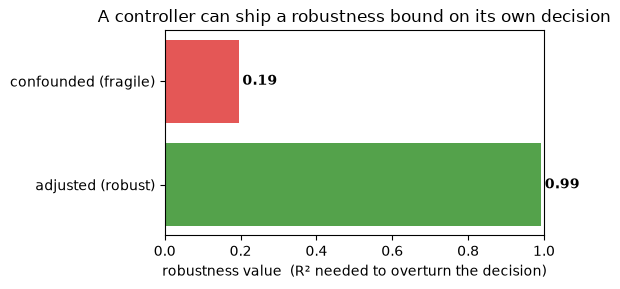

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(rv.index, rv["robustness_value"], color=["#54A24B", "#E45756"])
ax.set_xlim(0, 1)
ax.set_xlabel("robustness value  (R² needed to overturn the decision)")
ax.set_title("A controller can ship a robustness bound on its own decision")
for i, v in enumerate(rv["robustness_value"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 5 · Refutation: automatic robustness checks

Before trusting an effect, `chc` runs DoWhy-style refuters: permuting the treatment must collapse the
effect (**placebo → 0**), an irrelevant covariate must not change it (**random common cause**), and a
subsample must reproduce it (**subset**).

In [7]:
report = refute_effect(data, adjust_for=("z",))
pd.DataFrame({k: [v] for k, v in report.items()}).T.rename(columns={0: "value"})

,value
original,0.998507
placebo,0.000097
random_common_cause,0.998507
subset,0.99744
passes,True


### Takeaway
The causal layer is genuinely deep — adjustment, IV, Double ML, sensitivity, and refutation — so the
effect that feeds the controller is *interventional and stress-tested*, not a naive slope.